In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window

spark = (
    SparkSession.builder
    .appName('AzureDE-InterviewPrep')
    .master('local[*]')
    .config('spark.sql.shuffle.partitions', '4')
    .getOrCreate()
)
spark


In [3]:
spark.createDataFrame( [ ('e1', 'Sales', 70000), ('e2', 'Sales', 80000), ('e3', 'Sales', 80000), ('e4', 'Eng', 90000), ('e5', 'Eng', 95000), ('e6', 'Eng', 85000), ], ['emp_id', 'dept', 'salary'], ).createOrReplaceTempView('emp')

# A1. Design fact_sales + dims (columns, PK/FK).
                 dim_product
                      |
                      |
dim_date -----> fact_sales <----- dim_store
                      |
                      |
                dim_customer


# A2. Implement sample tables as temp views.

In [7]:
# create a dim_product
products = spark.createDataFrame(
    [
        (1, "Laptop", "Electronics", "Dell"),
        (2, "Phone", "Electronics", "Samsung"),
        (3, "Shoes", "Fashion", "Nike"),
        (4, "Shirt", "Fashion", "Puma"),
    ],
    ["product_key", "product_name", "category", "brand"]
)

products.createOrReplaceTempView("dim_product")

# create a dim_store
stores = spark.createDataFrame(
    [
        (101, "Store A", "Bengaluru", "South"),
        (102, "Store B", "Mumbai", "West"),
        (103, "Store C", "Delhi", "North"),
    ],
    ["store_key", "store_name", "city", "region"]
)

stores.createOrReplaceTempView("dim_store")

# create a dim_customer
customers = spark.createDataFrame(
    [
        (1001, "Alice", "Bengaluru"),
        (1002, "Bob", "Mumbai"),
        (1003, "Charlie", "Delhi"),
    ],
    ["customer_key", "customer_name", "city"]
)

customers.createOrReplaceTempView("dim_customer")

# create a dim_date
dates = spark.createDataFrame(
    [
        (20240101, "2024-01-01", 1, 1, 2024),
        (20240102, "2024-01-02", 1, 1, 2024),
        (20240201, "2024-02-01", 2, 1, 2024),
        (20240202, "2024-02-02", 2, 1, 2024),
    ],
    ["date_key", "full_date", "month", "quarter", "year"]
)

dates.createOrReplaceTempView("dim_date")

# create a fact_sales
sales = spark.createDataFrame(
    [
        (1, 20240101, 1, 101, 1001, 2, 50000, 0, 100000),
        (2, 20240101, 2, 101, 1001, 1, 30000, 1000, 29000),
        (3, 20240102, 3, 102, 1002, 2, 3000, 200, 5800),
        (4, 20240201, 1, 101, 1003, 1, 50000, 2000, 48000),
        (5, 20240202, 4, 103, 1002, 3, 2000, 100, 5900),
        (6, 20240202, 2, 102, 1003, 2, 30000, 500, 59500),
    ],
    [
        "sales_id",
        "date_key",
        "product_key",
        "store_key",
        "customer_key",
        "quantity",
        "unit_price",
        "discount",
        "net_amount"
    ]
)

sales.createOrReplaceTempView("fact_sales")

In [10]:
spark.sql("SELECT * FROM fact_sales").show()

spark.sql("SELECT * FROM dim_product").show()

spark.sql("SELECT * FROM dim_store").show()

spark.sql("SELECT * FROM dim_customer").show()

spark.sql("SELECT * FROM dim_date").show()

+--------+--------+-----------+---------+------------+--------+----------+--------+----------+
|sales_id|date_key|product_key|store_key|customer_key|quantity|unit_price|discount|net_amount|
+--------+--------+-----------+---------+------------+--------+----------+--------+----------+
|       1|20240101|          1|      101|        1001|       2|     50000|       0|    100000|
|       2|20240101|          2|      101|        1001|       1|     30000|    1000|     29000|
|       3|20240102|          3|      102|        1002|       2|      3000|     200|      5800|
|       4|20240201|          1|      101|        1003|       1|     50000|    2000|     48000|
|       5|20240202|          4|      103|        1002|       3|      2000|     100|      5900|
|       6|20240202|          2|      102|        1003|       2|     30000|     500|     59500|
+--------+--------+-----------+---------+------------+--------+----------+--------+----------+

+-----------+------------+-----------+-------+
|p

# A3. SQL: top products; revenue by store/month

In [14]:
spark.sql("""
SELECT
    p.product_key,
    p.product_name,
    p.category,
    SUM(f.net_amount) AS total_revenue
FROM fact_sales f
JOIN dim_product p
    ON f.product_key = p.product_key
GROUP BY
    p.product_key,
    p.product_name,
    p.category
ORDER BY total_revenue DESC
""").show()

spark.sql("""
SELECT
    p.product_name,
    SUM(f.net_amount) AS revenue
FROM fact_sales f
JOIN dim_product p
    ON f.product_key = p.product_key
GROUP BY p.product_name
ORDER BY revenue DESC
LIMIT 2
""").show()

spark.sql("""
SELECT
    s.store_name,
    d.year,
    d.month,
    SUM(f.net_amount) AS monthly_revenue
FROM fact_sales f
JOIN dim_store s
    ON f.store_key = s.store_key
JOIN dim_date d
    ON f.date_key = d.date_key
GROUP BY
    s.store_name,
    d.year,
    d.month
ORDER BY
    d.year,
    d.month,
    s.store_name
""").show()

+-----------+------------+-----------+-------------+
|product_key|product_name|   category|total_revenue|
+-----------+------------+-----------+-------------+
|          1|      Laptop|Electronics|       148000|
|          2|       Phone|Electronics|        88500|
|          4|       Shirt|    Fashion|         5900|
|          3|       Shoes|    Fashion|         5800|
+-----------+------------+-----------+-------------+

+------------+-------+
|product_name|revenue|
+------------+-------+
|      Laptop| 148000|
|       Phone|  88500|
+------------+-------+

+----------+----+-----+---------------+
|store_name|year|month|monthly_revenue|
+----------+----+-----+---------------+
|   Store A|2024|    1|         129000|
|   Store B|2024|    1|           5800|
|   Store A|2024|    2|          48000|
|   Store B|2024|    2|          59500|
|   Store C|2024|    2|           5900|
+----------+----+-----+---------------+



# A4. SCD1 vs SCD2 attribute choices.

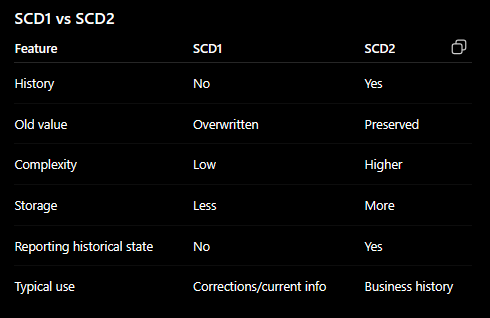

# A5. Approach for a slow SQL query.

In [15]:
spark.sql("""
SELECT
    p.product_name,
    SUM(f.net_amount) AS revenue
FROM fact_sales f
JOIN dim_product p
    ON f.product_key = p.product_key
GROUP BY p.product_name
""").explain("formatted")

== Physical Plan ==
AdaptiveSparkPlan (16)
+- HashAggregate (15)
   +- Exchange (14)
      +- HashAggregate (13)
         +- Project (12)
            +- SortMergeJoin Inner (11)
               :- Sort (5)
               :  +- Exchange (4)
               :     +- Project (3)
               :        +- Filter (2)
               :           +- Scan ExistingRDD (1)
               +- Sort (10)
                  +- Exchange (9)
                     +- Project (8)
                        +- Filter (7)
                           +- Scan ExistingRDD (6)


(1) Scan ExistingRDD
Output [9]: [sales_id#59L, date_key#60L, product_key#61L, store_key#62L, customer_key#63L, quantity#64L, unit_price#65L, discount#66L, net_amount#67L]
Arguments: [sales_id#59L, date_key#60L, product_key#61L, store_key#62L, customer_key#63L, quantity#64L, unit_price#65L, discount#66L, net_amount#67L], MapPartitionsRDD[74] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) 

SQL tab
   ↓
Stages
   ↓
Tasks

In [16]:
spark.sql("""
SELECT /*+ BROADCAST(p) */
    p.product_name,
    SUM(f.net_amount) AS revenue
FROM fact_sales f
JOIN dim_product p
    ON f.product_key = p.product_key
GROUP BY p.product_name
""").show()

+------------+-------+
|product_name|revenue|
+------------+-------+
|       Shoes|   5800|
|      Laptop| 148000|
|       Phone|  88500|
|       Shirt|   5900|
+------------+-------+



A1 → Star schema
     fact_sales + dimensions
     PK/FK

A2 → Temp views
     createOrReplaceTempView()

A3 → JOIN + GROUP BY + SUM
     product revenue
     store/month revenue

A4 → SCD1 = overwrite
     SCD2 = maintain history

A5 → EXPLAIN + Spark UI
     shuffle
     joins
     partition pruning
     skew
     small files
     AQE